# Telecom Customer Churn — Data Understanding

## Objective

The objective of this project is to develop a customer churn intelligence system
that identifies customers with elevated churn risk and supports business
prioritization for retention.

This notebook focuses exclusively on understanding the available telecom
customer dataset before preprocessing and model development.

The analysis will establish:

- the structure and granularity of the dataset,
- the meaning and type of available variables,
- the distribution of customer attributes,
- the distribution of churn,
- potential data-quality concerns,
- relationships between customer characteristics and churn,
- and the limitations of the available data for advanced churn analysis.

In [8]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
e:\Churn Prediction\.venv\Scripts\python.exe

Python version:
3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [9]:
# ============================================================================
# LIBRARY IMPORTS
# ============================================================================
# Import the core libraries required for dataset inspection, numerical
# analysis, and visualization during the data-understanding stage.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# ============================================================================
# DATA INGESTION
# ============================================================================
# Define the raw dataset location relative to the notebook directory.
# The project keeps the original data unchanged inside the raw-data layer.

from pathlib import Path

DATA_PATH = (
    Path("../data/raw")
    / "telecom-churn-case-study-hackathon-C33"
    / "train.csv"
)

# Resolve the path to verify exactly which file is being accessed.
print(f"Dataset path: {DATA_PATH.resolve()}")

# Load the training dataset without applying cleaning or transformation.
df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset path: E:\Churn Prediction\data\raw\telecom-churn-case-study-hackathon-C33\train.csv

Dataset loaded successfully.
Rows    : 69999
Columns : 172


In [22]:
# ============================================================================
# RAW DATA DIRECTORY INSPECTION
# ============================================================================
# Verify the raw-data directory and inspect the files available in the
# telecom churn case-study dataset.

raw_dir = Path("../data/raw")

print("Raw data directory:")
print(raw_dir.resolve())

print("\nContents:")
for item in raw_dir.iterdir():
    print(item)

Raw data directory:
E:\Churn Prediction\data\raw

Contents:
..\data\raw\telecom-churn-case-study-hackathon-C33


In [23]:
# ============================================================================
# DATASET FILE INSPECTION
# ============================================================================
# Inspect the files contained within the telecom churn case-study dataset.

dataset_dir = raw_dir / "telecom-churn-case-study-hackathon-C33"

print("Dataset files:\n")

for item in dataset_dir.iterdir():
    print(item.name)

Dataset files:

data_dictionary.csv
sample.csv
test.csv
train.csv


In [24]:
# ============================================================================
# INITIAL DATA SNAPSHOT
# ============================================================================
# Inspect representative records to understand the structure of the
# customer-level observations before performing detailed analysis.

display(df.head())

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


In [25]:
# ============================================================================
# DATASET STRUCTURE
# ============================================================================
# Review data types, non-null counts, and memory usage to identify potential
# type inconsistencies and fields requiring further investigation.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Columns: 172 entries, id to churn_probability
dtypes: float64(135), int64(28), str(9)
memory usage: 91.9 MB


In [26]:
# ============================================================================
# FEATURE INVENTORY
# ============================================================================
# Enumerate the available attributes to establish the feature space and
# distinguish customer identifiers, explanatory variables, and the churn
# outcome used for supervised learning.

print("Available features:\n")

for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")

Available features:

01. id
02. circle_id
03. loc_og_t2o_mou
04. std_og_t2o_mou
05. loc_ic_t2o_mou
06. last_date_of_month_6
07. last_date_of_month_7
08. last_date_of_month_8
09. arpu_6
10. arpu_7
11. arpu_8
12. onnet_mou_6
13. onnet_mou_7
14. onnet_mou_8
15. offnet_mou_6
16. offnet_mou_7
17. offnet_mou_8
18. roam_ic_mou_6
19. roam_ic_mou_7
20. roam_ic_mou_8
21. roam_og_mou_6
22. roam_og_mou_7
23. roam_og_mou_8
24. loc_og_t2t_mou_6
25. loc_og_t2t_mou_7
26. loc_og_t2t_mou_8
27. loc_og_t2m_mou_6
28. loc_og_t2m_mou_7
29. loc_og_t2m_mou_8
30. loc_og_t2f_mou_6
31. loc_og_t2f_mou_7
32. loc_og_t2f_mou_8
33. loc_og_t2c_mou_6
34. loc_og_t2c_mou_7
35. loc_og_t2c_mou_8
36. loc_og_mou_6
37. loc_og_mou_7
38. loc_og_mou_8
39. std_og_t2t_mou_6
40. std_og_t2t_mou_7
41. std_og_t2t_mou_8
42. std_og_t2m_mou_6
43. std_og_t2m_mou_7
44. std_og_t2m_mou_8
45. std_og_t2f_mou_6
46. std_og_t2f_mou_7
47. std_og_t2f_mou_8
48. std_og_t2c_mou_6
49. std_og_t2c_mou_7
50. std_og_t2c_mou_8
51. std_og_mou_6
52. std_og_mou

In [27]:
# ============================================================================
# DATA TYPE SUMMARY
# ============================================================================
# Summarize the number of features belonging to each data type.
# This provides a high-level view of the dataset representation before
# examining individual variables and data-quality issues.

dtype_summary = df.dtypes.value_counts()

print("Feature distribution by data type:\n")
print(dtype_summary)

Feature distribution by data type:

float64    135
int64       28
str          9
Name: count, dtype: int64


In [28]:
# ============================================================================
# FEATURE TYPE INVENTORY
# ============================================================================
# Display the features grouped by their current pandas data type.
# This helps identify numeric, categorical, and date-related variables that
# may require different treatment during later preprocessing.

for dtype in df.dtypes.unique():
    print(f"\n{'=' * 70}")
    print(f"Data type: {dtype}")
    print(f"{'=' * 70}")
    
    print(df.select_dtypes(include=[dtype]).columns.tolist())


Data type: int64
['id', 'circle_id', 'total_rech_num_6', 'total_rech_num_7', 'total_rech_num_8', 'total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8', 'max_rech_amt_6', 'max_rech_amt_7', 'max_rech_amt_8', 'last_day_rch_amt_6', 'last_day_rch_amt_7', 'last_day_rch_amt_8', 'monthly_2g_6', 'monthly_2g_7', 'monthly_2g_8', 'sachet_2g_6', 'sachet_2g_7', 'sachet_2g_8', 'monthly_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'sachet_3g_6', 'sachet_3g_7', 'sachet_3g_8', 'aon', 'churn_probability']

Data type: float64
['loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou', 'arpu_6', 'arpu_7', 'arpu_8', 'onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8', 'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8', 'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8', 'loc_og_t2c_mou_6', 'loc_og_

In [29]:
# ============================================================================
# MISSING VALUE ANALYSIS
# ============================================================================
# Quantify missing observations for every feature to identify variables with
# incomplete coverage and assess the extent of missingness in the raw dataset.

missing_count = df.isna().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
)

print(f"Features with missing values: {len(missing_summary)}")
print(f"Total missing observations: {missing_count.sum()}")

display(missing_summary)

Features with missing values: 125
Total missing observations: 1835086


,missing_count,missing_percentage
max_rech_data_6,52431,74.902499
count_rech_3g_6,52431,74.902499
arpu_2g_6,52431,74.902499
date_of_last_rech_data_6,52431,74.902499
total_rech_data_6,52431,74.902499
...,...,...
last_date_of_month_8,733,1.047158
std_og_t2o_mou,702,1.002871
loc_ic_t2o_mou,702,1.002871
loc_og_t2o_mou,702,1.002871


In [30]:
# ============================================================================
# MISSINGNESS DISTRIBUTION
# ============================================================================
# Examine how missing values are distributed across features rather than
# treating all missing observations as a single data-quality category.

missing_summary["missing_percentage"].describe()

count    125.000000
mean      20.972711
std       30.135231
min        0.570008
25%        3.838626
50%        3.954342
75%        5.290076
max       74.902499
Name: missing_percentage, dtype: float64

In [31]:
# ============================================================================
# MISSINGNESS GROUPS
# ============================================================================
# Group features into broad missingness ranges to identify whether missing
# values are concentrated in a small number of heavily incomplete variables
# or distributed across the dataset.

missing_percentage = missing_summary["missing_percentage"]

print("Features with > 50% missing:")
print((missing_percentage > 50).sum())

print("\nFeatures with 20%–50% missing:")
print(((missing_percentage >= 20) & (missing_percentage <= 50)).sum())

print("\nFeatures with 5%–20% missing:")
print(((missing_percentage >= 5) & (missing_percentage < 20)).sum())

print("\nFeatures with < 5% missing:")
print((missing_percentage < 5).sum())

Features with > 50% missing:
30

Features with 20%–50% missing:
0

Features with 5%–20% missing:
29

Features with < 5% missing:
66


In [32]:
# ============================================================================
# HIGH-MISSINGNESS FEATURES
# ============================================================================
# Identify features with more than 50% missing observations.
# These features require semantic investigation before any removal decision.

high_missing_features = (
    missing_summary[missing_summary["missing_percentage"] > 50]
    .sort_values("missing_percentage", ascending=False)
)

print(f"Number of features with >50% missing: {len(high_missing_features)}")

display(high_missing_features)

Number of features with >50% missing: 30


,missing_count,missing_percentage
max_rech_data_6,52431,74.902499
count_rech_3g_6,52431,74.902499
arpu_2g_6,52431,74.902499
date_of_last_rech_data_6,52431,74.902499
total_rech_data_6,52431,74.902499
night_pck_user_6,52431,74.902499
fb_user_6,52431,74.902499
count_rech_2g_6,52431,74.902499
av_rech_amt_data_6,52431,74.902499
arpu_3g_6,52431,74.902499


In [33]:
# ============================================================================
# INVESTIGATING DATA-RECHARGE MISSINGNESS
# ============================================================================
# Check whether customers with missing data-recharge information also show
# zero data usage. This helps distinguish meaningful absence of activity
# from genuine data-quality problems.

data_recharge_missing = df["total_rech_data_6"].isna()

print("Customers with total_rech_data_6 missing:")
print(data_recharge_missing.sum())

print("\nCustomers with total_rech_data_6 available:")
print((~data_recharge_missing).sum())

print("\nData usage among customers with missing recharge information:")

display(
    df.loc[
        data_recharge_missing,
        ["vol_2g_mb_6", "vol_3g_mb_6"]
    ].describe()
)

Customers with total_rech_data_6 missing:
52431

Customers with total_rech_data_6 available:
17568

Data usage among customers with missing recharge information:


,vol_2g_mb_6,vol_3g_mb_6
count,52431.0,52431.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [34]:
# ============================================================================
# INVESTIGATING DATA-RECHARGE MISSINGNESS
# ============================================================================
# Check whether customers with missing data-recharge information also show
# zero data usage. This helps distinguish meaningful absence of activity
# from genuine data-quality problems.

data_recharge_missing = df["total_rech_data_6"].isna()

print("Customers with total_rech_data_6 missing:")
print(data_recharge_missing.sum())

print("\nCustomers with total_rech_data_6 available:")
print((~data_recharge_missing).sum())

print("\nData usage among customers with missing recharge information:")

display(
    df.loc[
        data_recharge_missing,
        ["vol_2g_mb_6", "vol_3g_mb_6"]
    ].describe()
)

Customers with total_rech_data_6 missing:
52431

Customers with total_rech_data_6 available:
17568

Data usage among customers with missing recharge information:


,vol_2g_mb_6,vol_3g_mb_6
count,52431.0,52431.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [35]:
# ============================================================================
# CUSTOMER ID UNIQUENESS
# ============================================================================
# Verify whether each customer identifier corresponds to exactly one record.
# Duplicate customer records can distort statistical analysis and model
# evaluation if they are not handled correctly.

duplicate_id_count = df["id"].duplicated().sum()
unique_customer_count = df["id"].nunique()

print(f"Total records          : {len(df)}")
print(f"Unique customer IDs    : {unique_customer_count}")
print(f"Duplicate ID records  : {duplicate_id_count}")

print("\nID uniqueness check:")

if duplicate_id_count == 0:
    print("Each customer ID is unique.")
else:
    print("Duplicate customer IDs are present.")

Total records          : 69999
Unique customer IDs    : 69999
Duplicate ID records  : 0

ID uniqueness check:
Each customer ID is unique.


In [36]:
# ============================================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================================
# Examine the distribution of the churn target to determine class balance
# before model development.

churn_counts = df["churn_probability"].value_counts().sort_index()
churn_percentages = df["churn_probability"].value_counts(
    normalize=True
).sort_index() * 100

churn_summary = pd.DataFrame({
    "customer_count": churn_counts,
    "percentage": churn_percentages
})

display(churn_summary)

,customer_count,percentage
churn_probability,,
0,62867,89.811283
1,7132,10.188717


In [37]:
# ============================================================================
# TARGET VALIDITY CHECK
# ============================================================================
# Verify that the churn target contains only the expected binary classes.
# This confirms that the target is suitable for binary classification.

print("Unique target values:")
print(df["churn_probability"].unique())

print("\nTarget data type:")
print(df["churn_probability"].dtype)

print("\nMissing target values:")
print(df["churn_probability"].isna().sum())

Unique target values:
[0 1]

Target data type:
int64

Missing target values:
0


In [38]:
# ============================================================================
# NON-NUMERIC FEATURE IDENTIFICATION
# ============================================================================
# Identify string/object columns before deciding how dates and categorical
# variables should be represented during preprocessing.

non_numeric_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Non-numeric features:")
for column in non_numeric_columns:
    print(f"- {column}")

print(f"\nTotal non-numeric features: {len(non_numeric_columns)}")

Non-numeric features:
- last_date_of_month_6
- last_date_of_month_7
- last_date_of_month_8
- date_of_last_rech_6
- date_of_last_rech_7
- date_of_last_rech_8
- date_of_last_rech_data_6
- date_of_last_rech_data_7
- date_of_last_rech_data_8

Total non-numeric features: 9


In [39]:
# ============================================================================
# DATE FEATURE INSPECTION
# ============================================================================
# Inspect representative values and missingness for all date-related fields.
# This determines the date format and whether each field is consistently
# populated before any date conversion is performed.

date_columns = [
    "last_date_of_month_6",
    "last_date_of_month_7",
    "last_date_of_month_8",
    "date_of_last_rech_6",
    "date_of_last_rech_7",
    "date_of_last_rech_8",
    "date_of_last_rech_data_6",
    "date_of_last_rech_data_7",
    "date_of_last_rech_data_8"
]

date_summary = pd.DataFrame({
    "dtype": df[date_columns].dtypes,
    "missing_count": df[date_columns].isna().sum(),
    "missing_percentage": df[date_columns].isna().mean() * 100,
    "unique_values": df[date_columns].nunique()
})

display(date_summary)

print("\nSample date values:")
display(df[date_columns].head())

,dtype,missing_count,missing_percentage,unique_values
last_date_of_month_6,str,0,0.000000,1
last_date_of_month_7,str,399,0.570008,1
last_date_of_month_8,str,733,1.047158,1
date_of_last_rech_6,str,1101,1.572880,30
date_of_last_rech_7,str,1234,1.762882,31
date_of_last_rech_8,str,2461,3.515765,31
date_of_last_rech_data_6,str,52431,74.902499,30
date_of_last_rech_data_7,str,52134,74.478207,31
date_of_last_rech_data_8,str,51582,73.689624,31



Sample date values:


,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8
0,6/30/2014,7/31/2014,8/31/2014,6/22/2014,7/10/2014,8/24/2014,NaN,NaN,NaN
1,6/30/2014,7/31/2014,8/31/2014,6/12/2014,7/10/2014,8/26/2014,NaN,7/8/2014,NaN
2,6/30/2014,7/31/2014,8/31/2014,6/11/2014,7/22/2014,8/24/2014,NaN,NaN,NaN
3,6/30/2014,7/31/2014,8/31/2014,6/15/2014,7/21/2014,8/25/2014,NaN,NaN,NaN
4,6/30/2014,7/31/2014,8/31/2014,6/25/2014,7/26/2014,8/30/2014,6/25/2014,7/23/2014,8/20/2014


In [40]:
# ============================================================================
# NUMERICAL FEATURE DISTRIBUTION SUMMARY
# ============================================================================
# Summarize the numerical variables to identify scale differences,
# zero-heavy features, extreme ranges, and potential distribution issues.
# No transformation is performed at this stage.

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

numeric_summary = df[numeric_columns].describe().T

numeric_summary["zero_count"] = (df[numeric_columns] == 0).sum()
numeric_summary["zero_percentage"] = (
    numeric_summary["zero_count"] / len(df) * 100
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,zero_count,zero_percentage
id,69999.0,34999.000000,20207.115084,0.0,17499.5,34999.0,52498.5,69998.00,1,0.001429
circle_id,69999.0,109.000000,0.000000,109.0,109.0,109.0,109.0,109.00,0,0.000000
loc_og_t2o_mou,69297.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,69297,98.997129
std_og_t2o_mou,69297.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,69297,98.997129
loc_ic_t2o_mou,69297.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,69297,98.997129
...,...,...,...,...,...,...,...,...,...,...
aon,69999.0,1220.639709,952.426321,180.0,468.0,868.0,1813.0,4337.00,0,0.000000
aug_vbc_3g,69999.0,68.108597,269.328659,0.0,0.0,0.0,0.0,12916.22,58348,83.355477
jul_vbc_3g,69999.0,65.935830,267.899034,0.0,0.0,0.0,0.0,9165.60,58747,83.925485
jun_vbc_3g,69999.0,60.076740,257.226810,0.0,0.0,0.0,0.0,11166.21,59445,84.922642


In [41]:
# ============================================================================
# CONSTANT AND NEAR-CONSTANT FEATURE ANALYSIS
# ============================================================================
# Identify numerical features with no variation or extremely low variation.
# Constant features contain no predictive information, while near-constant
# features require additional investigation before removal.

feature_columns = [
    column for column in df.columns
    if column != "churn_probability"
]

constant_features = []
near_constant_features = []

for column in feature_columns:

    value_counts = df[column].value_counts(dropna=False, normalize=True)

    dominant_percentage = value_counts.iloc[0] * 100

    if df[column].nunique(dropna=False) == 1:
        constant_features.append(column)

    elif dominant_percentage >= 99:
        near_constant_features.append(
            (column, dominant_percentage)
        )

print("Constant features:")
for column in constant_features:
    print(f"- {column}")

print(f"\nTotal constant features: {len(constant_features)}")

print("\nNear-constant features (dominant value >= 99%):")
for column, percentage in near_constant_features:
    print(f"- {column}: {percentage:.2f}%")

print(f"\nTotal near-constant features: {len(near_constant_features)}")

Constant features:
- circle_id
- last_date_of_month_6

Total constant features: 2

Near-constant features (dominant value >= 99%):
- last_date_of_month_7: 99.43%

Total near-constant features: 1


In [42]:
# ============================================================================
# DUPLICATE FEATURE ANALYSIS
# ============================================================================
# Identify columns containing identical values across the dataset.
# Duplicate features provide redundant information and can be removed during
# data cleaning without affecting the underlying information content.

feature_df = df.drop(columns=["churn_probability"])

duplicate_features = []

columns = feature_df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if feature_df[columns[i]].equals(feature_df[columns[j]]):
            duplicate_features.append(
                (columns[i], columns[j])
            )

print(f"Identical feature pairs found: {len(duplicate_features)}")

if duplicate_features:
    print("\nDuplicate feature pairs:")
    for col1, col2 in duplicate_features:
        print(f"- {col1} == {col2}")
else:
    print("No identical feature pairs found.")

Identical feature pairs found: 6

Duplicate feature pairs:
- loc_og_t2o_mou == std_og_t2o_mou
- loc_og_t2o_mou == loc_ic_t2o_mou
- std_og_t2o_mou == loc_ic_t2o_mou
- std_og_t2c_mou_6 == std_ic_t2o_mou_6
- std_og_t2c_mou_7 == std_ic_t2o_mou_7
- std_og_t2c_mou_8 == std_ic_t2o_mou_8


In [43]:
# ============================================================================
# NUMERICAL FEATURE RELATIONSHIP WITH CHURN
# ============================================================================
# Measure the relationship between each numerical feature and the binary churn
# outcome. Pearson correlation is used here as an initial screening measure;
# this is not treated as evidence of causality.

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Exclude the target from the feature list.
numeric_features.remove("churn_probability")

correlation_with_churn = (
    df[numeric_features + ["churn_probability"]]
    .corr(numeric_only=True)["churn_probability"]
    .drop("churn_probability")
    .sort_values()
)

print("Features most negatively associated with churn:")
display(correlation_with_churn.head(15))

print("\nFeatures most positively associated with churn:")
display(correlation_with_churn.tail(15))

Features most negatively associated with churn:


total_ic_mou_8       -0.187566
total_rech_num_8     -0.167043
total_rech_amt_8     -0.160455
max_rech_amt_8       -0.159131
arpu_8               -0.157566
total_og_mou_8       -0.149325
last_day_rch_amt_8   -0.139611
aon                  -0.135177
loc_ic_mou_8         -0.128784
loc_ic_t2m_mou_8     -0.124840
total_ic_mou_7       -0.120197
loc_og_t2m_mou_8     -0.113309
loc_og_mou_8         -0.108821
loc_ic_t2m_mou_7     -0.099544
loc_ic_mou_7         -0.098318
Name: churn_probability, dtype: float64


Features most positively associated with churn:


std_og_t2t_mou_6    0.084323
roam_ic_mou_8       0.085761
roam_og_mou_7       0.086646
roam_og_mou_8       0.098703
std_og_mou_6        0.107870
circle_id                NaN
loc_og_t2o_mou           NaN
std_og_t2o_mou           NaN
loc_ic_t2o_mou           NaN
std_og_t2c_mou_6         NaN
std_og_t2c_mou_7         NaN
std_og_t2c_mou_8         NaN
std_ic_t2o_mou_6         NaN
std_ic_t2o_mou_7         NaN
std_ic_t2o_mou_8         NaN
Name: churn_probability, dtype: float64

In [44]:
# ============================================================================
# TEMPORAL BEHAVIOR COMPARISON
# ============================================================================
# Compare selected customer-behavior measures across June, July, and August
# separately for churned and non-churned customers.
#
# This is an exploratory analysis to determine whether behavioral trajectories
# differ between the two outcome groups before feature engineering.

temporal_features = {
    "ARPU": ["arpu_6", "arpu_7", "arpu_8"],
    "Recharge Amount": [
        "total_rech_amt_6",
        "total_rech_amt_7",
        "total_rech_amt_8"
    ],
    "Recharge Count": [
        "total_rech_num_6",
        "total_rech_num_7",
        "total_rech_num_8"
    ],
    "Outgoing Usage": [
        "total_og_mou_6",
        "total_og_mou_7",
        "total_og_mou_8"
    ],
    "Incoming Usage": [
        "total_ic_mou_6",
        "total_ic_mou_7",
        "total_ic_mou_8"
    ]
}

for metric, columns in temporal_features.items():

    print(f"\n{'=' * 70}")
    print(metric)
    print(f"{'=' * 70}")

    summary = (
        df.groupby("churn_probability")[columns]
        .mean()
        .T
    )

    summary.columns = ["Non-Churn", "Churn"]

    display(summary)


ARPU


,Non-Churn,Churn
arpu_6,280.280668,308.289067
arpu_7,284.891073,219.081400
arpu_8,297.535694,114.226380



Recharge Amount


,Non-Churn,Churn
total_rech_amt_6,325.570888,350.784072
total_rech_amt_7,331.234352,244.295149
total_rech_amt_8,346.878712,120.821228



Recharge Count


,Non-Churn,Churn
total_rech_num_6,7.504939,8.109366
total_rech_num_7,7.856173,6.388811
total_rech_num_8,7.629774,3.656338



Outgoing Usage


,Non-Churn,Churn
total_og_mou_6,301.242079,352.370766
total_og_mou_7,318.252422,242.877399
total_og_mou_8,328.550893,92.624937



Incoming Usage


,Non-Churn,Churn
total_ic_mou_6,206.643635,138.597825
total_ic_mou_7,213.892542,95.972761
total_ic_mou_8,216.701665,37.919282


In [45]:
# ============================================================================
# BEHAVIORAL CHANGE ANALYSIS
# ============================================================================
# Quantify month-to-month and overall changes in key customer engagement
# and monetization indicators.
#
# The purpose is to determine whether churned customers exhibit a
# systematically different behavioral trajectory from non-churned customers.
#
# These measurements are exploratory. They will not yet be used as model
# features or treated as evidence of causality.

change_features = {
    "ARPU": ["arpu_6", "arpu_7", "arpu_8"],

    "Recharge Amount": [
        "total_rech_amt_6",
        "total_rech_amt_7",
        "total_rech_amt_8"
    ],

    "Recharge Count": [
        "total_rech_num_6",
        "total_rech_num_7",
        "total_rech_num_8"
    ],

    "Outgoing Usage": [
        "total_og_mou_6",
        "total_og_mou_7",
        "total_og_mou_8"
    ],

    "Incoming Usage": [
        "total_ic_mou_6",
        "total_ic_mou_7",
        "total_ic_mou_8"
    ]
}

for metric, columns in change_features.items():

    temp = df[columns + ["churn_probability"]].copy()

    # Month-to-month behavioral changes.
    temp["Jun_to_Jul"] = temp[columns[1]] - temp[columns[0]]
    temp["Jul_to_Aug"] = temp[columns[2]] - temp[columns[1]]

    # Overall change across the observed period.
    temp["Jun_to_Aug"] = temp[columns[2]] - temp[columns[0]]

    # Relative change from the June baseline.
    # Zero June values are excluded because percentage change would be undefined.
    temp["Jun_to_Aug_pct"] = np.where(
        temp[columns[0]] != 0,
        (
            (temp[columns[2]] - temp[columns[0]])
            / temp[columns[0]]
        ) * 100,
        np.nan
    )

    summary = (
        temp.groupby("churn_probability")[
            [
                "Jun_to_Jul",
                "Jul_to_Aug",
                "Jun_to_Aug",
                "Jun_to_Aug_pct"
            ]
        ]
        .mean()
    )

    summary.index = ["Non-Churn", "Churn"]

    print(f"\n{'=' * 70}")
    print(metric)
    print(f"{'=' * 70}")

    display(summary)


ARPU


,Jun_to_Jul,Jul_to_Aug,Jun_to_Aug,Jun_to_Aug_pct
Non-Churn,4.610405,12.64462,17.255025,2340.943206
Churn,-89.207667,-104.85502,-194.062687,1280.477901



Recharge Amount


,Jun_to_Jul,Jul_to_Aug,Jun_to_Aug,Jun_to_Aug_pct
Non-Churn,5.663464,15.64436,21.307824,50.275678
Churn,-106.488923,-123.47392,-229.962844,-44.012481



Recharge Count


,Jun_to_Jul,Jul_to_Aug,Jun_to_Aug,Jun_to_Aug_pct
Non-Churn,0.351234,-0.226399,0.124835,42.987080
Churn,-1.720555,-2.732473,-4.453029,-15.021558



Outgoing Usage


,Jun_to_Jul,Jul_to_Aug,Jun_to_Aug,Jun_to_Aug_pct
Non-Churn,17.010343,10.298471,27.308814,1313.680991
Churn,-109.493367,-150.252462,-259.745829,494.317796



Incoming Usage


,Jun_to_Jul,Jul_to_Aug,Jun_to_Aug,Jun_to_Aug_pct
Non-Churn,7.248907,2.809123,10.058030,273.901062
Churn,-42.625064,-58.053479,-100.678543,139.014316


In [49]:
# ============================================================================
# CUSTOMER-LEVEL DETERIORATION DISTRIBUTION
# ============================================================================
# Determine how frequently individual customers experience behavioral
# deterioration between June and August.
#
# Group averages can conceal substantial variation between customers.
# This analysis therefore measures the proportion of customers whose
# behavior increased, remained stable, or decreased.

deterioration_features = {
    "ARPU": ("arpu_6", "arpu_8"),
    "Recharge Amount": ("total_rech_amt_6", "total_rech_amt_8"),
    "Recharge Count": ("total_rech_num_6", "total_rech_num_8"),
    "Outgoing Usage": ("total_og_mou_6", "total_og_mou_8"),
    "Incoming Usage": ("total_ic_mou_6", "total_ic_mou_8")
}

for metric, (june_col, august_col) in deterioration_features.items():

    temp = df[[june_col, august_col, "churn_probability"]].copy()

    temp["change"] = temp[august_col] - temp[june_col]

    temp["behavior"] = np.select(
        [
            temp["change"] < 0,
            temp["change"] == 0,
            temp["change"] > 0
        ],
        [
            "Decreased",
            "Stable",
            "Increased"
        ],
        default="Unknown"
    )

    distribution = (
        pd.crosstab(
            temp["churn_probability"],
            temp["behavior"],
            normalize="index"
        ) * 100
    )

    distribution = distribution.reindex(
        columns=["Decreased", "Stable", "Increased"],
        fill_value=0
    )

    distribution.index = ["Non-Churn", "Churn"]

    print(f"\n{'=' * 70}")
    print(metric)
    print(f"{'=' * 70}")

    display(distribution.round(2))


ARPU


behavior,Decreased,Stable,Increased
Non-Churn,47.75,0.10,52.16
Churn,77.19,1.44,21.37



Recharge Amount


behavior,Decreased,Stable,Increased
Non-Churn,44.57,4.55,50.88
Churn,72.88,8.93,18.19



Recharge Count


behavior,Decreased,Stable,Increased
Non-Churn,47.51,11.10,41.39
Churn,69.59,8.65,21.76



Outgoing Usage


behavior,Decreased,Stable,Increased
Non-Churn,47.45,1.72,50.83
Churn,68.27,17.41,14.32



Incoming Usage


behavior,Decreased,Stable,Increased
Non-Churn,46.41,0.93,52.65
Churn,67.75,17.48,14.76


In [50]:
# ============================================================================
# MULTI-DIMENSIONAL BEHAVIORAL DETERIORATION
# ============================================================================
# Measure how many key behavioral dimensions deteriorate for each customer
# between June and August.
#
# The objective is to determine whether churned customers experience
# coordinated deterioration across multiple aspects of engagement and value.

behavior_pairs = {
    "ARPU": ("arpu_6", "arpu_8"),
    "Recharge Amount": ("total_rech_amt_6", "total_rech_amt_8"),
    "Recharge Count": ("total_rech_num_6", "total_rech_num_8"),
    "Outgoing Usage": ("total_og_mou_6", "total_og_mou_8"),
    "Incoming Usage": ("total_ic_mou_6", "total_ic_mou_8")
}

deterioration_count = pd.DataFrame(index=df.index)

for metric, (june_col, august_col) in behavior_pairs.items():

    deterioration_count[metric] = (
        df[august_col] < df[june_col]
    )

deterioration_count["Deterioration_Count"] = (
    deterioration_count.sum(axis=1)
)

deterioration_count["churn_probability"] = df["churn_probability"]

distribution = (
    pd.crosstab(
        deterioration_count["churn_probability"],
        deterioration_count["Deterioration_Count"],
        normalize="index"
    ) * 100
)

distribution.index = ["Non-Churn", "Churn"]

print("Distribution of simultaneous behavioral deterioration:\n")

display(distribution.round(2))

Distribution of simultaneous behavioral deterioration:



Deterioration_Count,0,1,2,3,4,5
Non-Churn,24.31,16.11,12.90,13.28,15.07,18.34
Churn,13.47,7.22,5.92,10.17,9.98,53.24


In [51]:
# ============================================================================
# CUSTOMER-LEVEL TRAJECTORY PATTERNS
# ============================================================================
# Classify each customer's June-to-July-to-August trajectory for selected
# behavioral metrics.
#
# The purpose is to determine whether churners exhibit sustained deterioration
# rather than isolated changes between two time points.
#
# Trajectory categories:
#   Decreasing      : June > July > August
#   Increasing      : June < July < August
#   Decline-Recover : June > July and July < August
#   Increase-Decline: June < July and July > August
#   Stable/Mixed    : all remaining patterns
#
# This remains exploratory analysis. The resulting categories are not yet
# treated as final customer states or business classes.

trajectory_features = {
    "ARPU": ["arpu_6", "arpu_7", "arpu_8"],
    "Recharge Amount": [
        "total_rech_amt_6",
        "total_rech_amt_7",
        "total_rech_amt_8"
    ],
    "Recharge Count": [
        "total_rech_num_6",
        "total_rech_num_7",
        "total_rech_num_8"
    ],
    "Outgoing Usage": [
        "total_og_mou_6",
        "total_og_mou_7",
        "total_og_mou_8"
    ],
    "Incoming Usage": [
        "total_ic_mou_6",
        "total_ic_mou_7",
        "total_ic_mou_8"
    ]
}

for metric, columns in trajectory_features.items():

    temp = df[columns + ["churn_probability"]].copy()

    june = temp[columns[0]]
    july = temp[columns[1]]
    august = temp[columns[2]]

    temp["trajectory"] = np.select(
        [
            (june > july) & (july > august),
            (june < july) & (july < august),
            (june > july) & (july < august),
            (june < july) & (july > august)
        ],
        [
            "Decreasing",
            "Increasing",
            "Decline-Recover",
            "Increase-Decline"
        ],
        default="Stable/Mixed"
    )

    distribution = (
        pd.crosstab(
            temp["churn_probability"],
            temp["trajectory"],
            normalize="index"
        ) * 100
    )

    trajectory_order = [
        "Decreasing",
        "Increasing",
        "Decline-Recover",
        "Increase-Decline",
        "Stable/Mixed"
    ]

    distribution = distribution.reindex(
        columns=trajectory_order,
        fill_value=0
    )

    distribution.index = ["Non-Churn", "Churn"]

    print(f"\n{'=' * 70}")
    print(metric)
    print(f"{'=' * 70}")

    display(distribution.round(2))


ARPU


trajectory,Decreasing,Increasing,Decline-Recover,Increase-Decline,Stable/Mixed
Non-Churn,18.91,21.09,30.36,28.54,1.09
Churn,38.66,6.81,12.79,28.00,13.74



Recharge Amount


trajectory,Decreasing,Increasing,Decline-Recover,Increase-Decline,Stable/Mixed
Non-Churn,14.08,18.45,28.08,27.73,11.67
Churn,28.95,4.60,8.65,26.28,31.52



Recharge Count


trajectory,Decreasing,Increasing,Decline-Recover,Increase-Decline,Stable/Mixed
Non-Churn,15.61,13.46,19.49,27.72,23.72
Churn,30.50,5.48,11.55,27.17,25.29



Outgoing Usage


trajectory,Decreasing,Increasing,Decline-Recover,Increase-Decline,Stable/Mixed
Non-Churn,19.45,20.63,27.31,28.03,4.58
Churn,30.89,4.21,5.24,24.38,35.28



Incoming Usage


trajectory,Decreasing,Increasing,Decline-Recover,Increase-Decline,Stable/Mixed
Non-Churn,18.63,21.36,27.51,29.26,3.24
Churn,29.75,4.33,5.62,25.42,34.87


In [52]:
# ============================================================================
# PERSISTENT DETERIORATION COUNT
# ============================================================================
# Measures how many behavioral dimensions show continuous deterioration
# across both observed monthly transitions:
#
#       June > July > August
#
# A metric is counted only when the customer declines in both transitions.
# This provides a stricter measure of persistent deterioration than comparing
# only the June and August endpoints.
#
# The resulting count ranges from 0 to 5 across the selected dimensions.

persistent_features = {
    "ARPU": ["arpu_6", "arpu_7", "arpu_8"],
    "Recharge Amount": [
        "total_rech_amt_6",
        "total_rech_amt_7",
        "total_rech_amt_8"
    ],
    "Recharge Count": [
        "total_rech_num_6",
        "total_rech_num_7",
        "total_rech_num_8"
    ],
    "Outgoing Usage": [
        "total_og_mou_6",
        "total_og_mou_7",
        "total_og_mou_8"
    ],
    "Incoming Usage": [
        "total_ic_mou_6",
        "total_ic_mou_7",
        "total_ic_mou_8"
    ]
}

persistent_count = pd.DataFrame(index=df.index)

for metric, columns in persistent_features.items():

    june = df[columns[0]]
    july = df[columns[1]]
    august = df[columns[2]]

    persistent_count[metric] = (
        (june > july) & (july > august)
    ).astype(int)

# Total number of dimensions showing persistent deterioration
persistent_count["persistent_deterioration_count"] = (
    persistent_count.sum(axis=1)
)

# Attach churn outcome for analysis
persistent_analysis = persistent_count.copy()
persistent_analysis["churn_probability"] = df["churn_probability"]

# Distribution by churn outcome
distribution = (
    pd.crosstab(
        persistent_analysis["churn_probability"],
        persistent_analysis["persistent_deterioration_count"],
        normalize="index"
    ) * 100
)

distribution.index = ["Non-Churn", "Churn"]

distribution = distribution.reindex(
    columns=range(6),
    fill_value=0
)

distribution.columns = [
    "0 dimensions",
    "1 dimension",
    "2 dimensions",
    "3 dimensions",
    "4 dimensions",
    "5 dimensions"
]

print("=" * 80)
print("PERSISTENT DETERIORATION DISTRIBUTION")
print("=" * 80)

display(distribution.round(2))

PERSISTENT DETERIORATION DISTRIBUTION


,0 dimensions,1 dimension,2 dimensions,3 dimensions,4 dimensions,5 dimensions
Non-Churn,56.71,20.57,10.15,6.53,3.97,2.07
Churn,41.56,18.73,9.94,9.58,9.55,10.64


In [53]:
# ============================================================================
# AVERAGE PERSISTENT DETERIORATION
# ============================================================================

summary = (
    persistent_analysis
    .groupby("churn_probability")["persistent_deterioration_count"]
    .agg(["mean", "median"])
)

summary.index = ["Non-Churn", "Churn"]

print("=" * 80)
print("AVERAGE PERSISTENT DETERIORATION")
print("=" * 80)

display(summary.round(2))

AVERAGE PERSISTENT DETERIORATION


,mean,median
Non-Churn,0.87,0.0
Churn,1.59,1.0


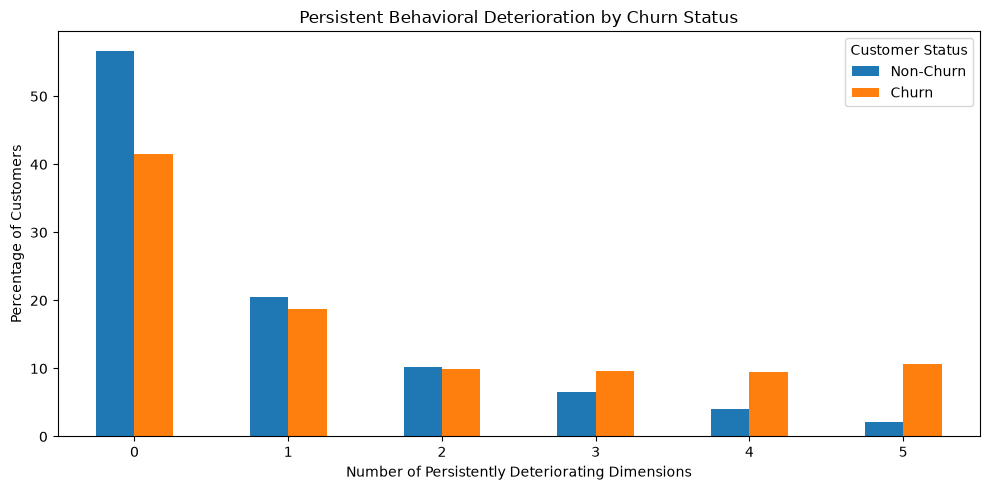

In [54]:
# ============================================================================
# PERSISTENT DETERIORATION DISTRIBUTION BY CHURN STATUS
# ============================================================================

plot_data = (
    pd.crosstab(
        persistent_analysis["persistent_deterioration_count"],
        persistent_analysis["churn_probability"],
        normalize="columns"
    ) * 100
)

plot_data.columns = ["Non-Churn", "Churn"]

plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Number of Persistently Deteriorating Dimensions")
plt.ylabel("Percentage of Customers")
plt.title("Persistent Behavioral Deterioration by Churn Status")
plt.xticks(rotation=0)
plt.legend(title="Customer Status")
plt.tight_layout()
plt.show()

In [55]:
# ============================================================================
# TEMPORAL FEATURE REDUNDANCY CHECK
# ============================================================================
# Compare the main temporal representations of customer behavior.
#
# The purpose is to determine whether:
#   1. raw monthly values,
#   2. June-to-August change, and
#   3. July-to-August change
#
# provide substantially different information or are highly correlated.
#
# This analysis is diagnostic only. No feature is removed at this stage.

temporal_features = {
    "ARPU": [
        "arpu_6",
        "arpu_7",
        "arpu_8"
    ],
    "Recharge Amount": [
        "total_rech_amt_6",
        "total_rech_amt_7",
        "total_rech_amt_8"
    ],
    "Recharge Count": [
        "total_rech_num_6",
        "total_rech_num_7",
        "total_rech_num_8"
    ],
    "Outgoing Usage": [
        "total_og_mou_6",
        "total_og_mou_7",
        "total_og_mou_8"
    ],
    "Incoming Usage": [
        "total_ic_mou_6",
        "total_ic_mou_7",
        "total_ic_mou_8"
    ]
}

temporal_analysis = pd.DataFrame(index=df.index)

for metric, columns in temporal_features.items():

    june = df[columns[0]]
    july = df[columns[1]]
    august = df[columns[2]]

    # Endpoint change across the complete observation period.
    temporal_analysis[f"{metric}_jun_aug_change"] = august - june

    # Most recent monthly change.
    temporal_analysis[f"{metric}_jul_aug_change"] = august - july

    # Persistent deterioration indicator.
    temporal_analysis[f"{metric}_persistent_decline"] = (
        (june > july) & (july > august)
    ).astype(int)

print("Temporal representations created:")
print(f"Features generated: {temporal_analysis.shape[1]}")

display(temporal_analysis.head())

Temporal representations created:
Features generated: 15


,ARPU_jun_aug_change,ARPU_jul_aug_change,ARPU_persistent_decline,Recharge Amount_jun_aug_change,Recharge Amount_jul_aug_change,Recharge Amount_persistent_decline,Recharge Count_jun_aug_change,Recharge Count_jul_aug_change,Recharge Count_persistent_decline,Outgoing Usage_jun_aug_change,Outgoing Usage_jul_aug_change,Outgoing Usage_persistent_decline,Incoming Usage_jun_aug_change,Incoming Usage_jul_aug_change,Incoming Usage_persistent_decline
0,-23.750,-79.482,0,-67,-55,1,-1,0,0,-77.58,-218.05,0,28.72,-12.48,0
1,42.953,-79.834,0,50,-95,0,2,1,0,31.66,0.93,0,21.60,-14.40,0
2,-60.806,-103.176,0,-70,-120,0,0,-2,0,-56.49,-99.36,0,-87.65,2.81,0
3,-45.267,-94.165,0,-30,-110,0,1,-1,0,-22.19,-42.14,0,-11.27,33.66,0
4,-139.143,-26.626,1,-168,-14,1,-5,-2,1,-47.50,-27.18,1,6.77,18.95,0


In [56]:
# ============================================================================
# TEMPORAL CORRELATION MATRIX
# ============================================================================
# Examine relationships among engineered temporal representations.
# High absolute correlation indicates that two representations may contain
# substantially overlapping information.

correlation_matrix = temporal_analysis.corr()

display(
    correlation_matrix.round(2)
)

,ARPU_jun_aug_change,ARPU_jul_aug_change,ARPU_persistent_decline,Recharge Amount_jun_aug_change,Recharge Amount_jul_aug_change,Recharge Amount_persistent_decline,Recharge Count_jun_aug_change,Recharge Count_jul_aug_change,Recharge Count_persistent_decline,Outgoing Usage_jun_aug_change,Outgoing Usage_jul_aug_change,Outgoing Usage_persistent_decline,Incoming Usage_jun_aug_change,Incoming Usage_jul_aug_change,Incoming Usage_persistent_decline
ARPU_jun_aug_change,1.00,0.58,-0.43,0.89,0.47,-0.37,0.61,0.34,-0.32,0.69,0.42,-0.32,0.28,0.17,-0.21
ARPU_jul_aug_change,0.58,1.00,-0.23,0.54,0.77,-0.22,0.35,0.53,-0.16,0.40,0.62,-0.19,0.15,0.23,-0.12
ARPU_persistent_decline,-0.43,-0.23,1.00,-0.38,-0.17,0.58,-0.36,-0.18,0.35,-0.33,-0.18,0.51,-0.18,-0.11,0.23
Recharge Amount_jun_aug_change,0.89,0.54,-0.38,1.00,0.56,-0.40,0.60,0.34,-0.34,0.65,0.42,-0.30,0.27,0.17,-0.20
Recharge Amount_jul_aug_change,0.47,0.77,-0.17,0.56,1.00,-0.21,0.32,0.53,-0.16,0.34,0.55,-0.15,0.13,0.20,-0.10
Recharge Amount_persistent_decline,-0.37,-0.22,0.58,-0.40,-0.21,1.00,-0.36,-0.21,0.39,-0.31,-0.19,0.40,-0.16,-0.11,0.21
Recharge Count_jun_aug_change,0.61,0.35,-0.36,0.60,0.32,-0.36,1.00,0.60,-0.46,0.56,0.34,-0.30,0.25,0.15,-0.22
Recharge Count_jul_aug_change,0.34,0.53,-0.18,0.34,0.53,-0.21,0.60,1.00,-0.24,0.30,0.49,-0.16,0.13,0.20,-0.12
Recharge Count_persistent_decline,-0.32,-0.16,0.35,-0.34,-0.16,0.39,-0.46,-0.24,1.00,-0.26,-0.14,0.27,-0.16,-0.09,0.17
Outgoing Usage_jun_aug_change,0.69,0.40,-0.33,0.65,0.34,-0.31,0.56,0.30,-0.26,1.00,0.62,-0.37,0.29,0.17,-0.23


# Final Findings, Limitations & Readiness

## 1. Dataset Overview

The dataset contains **69,999 unique customers** represented across **172 columns**, including the binary target variable `churn_probability`.

The available customer information covers three monthly observation periods — **June, July, and August** — and includes:

* Customer and geographic identifiers
* ARPU and recharge behaviour
* Outgoing and incoming usage
* Local, STD, roaming and other usage categories
* Data usage and recharge information
* Customer tenure (`aon`)
* Recharge dates and other temporal information

The dataset therefore provides more than a static customer snapshot. It contains repeated monthly observations that allow customer behaviour to be examined as a short temporal trajectory.

The competition description also explicitly characterizes the task as predicting churn based on **temporal behaviour**.

---

## 2. Major Findings from Data Understanding

### 2.1 Churn is an imbalanced outcome

The target distribution is:

| Customer Class |  Count | Percentage |
| -------------- | -----: | ---------: |
| Non-Churn      | 62,867 |     89.81% |
| Churn          |  7,132 |     10.19% |

The dataset therefore contains approximately **8.8 non-churn customers for every churn customer**.

This means that accuracy alone will not be an appropriate measure of model quality. Later model evaluation should consider metrics such as:

* Precision
* Recall
* F1-score
* PR-AUC
* ROC-AUC
* Calibration
* Business-oriented evaluation

The imbalance is also important because false negatives and false positives do not have equal business consequences.

---

## 3. Customer Behaviour Changes Across Time

The monthly analysis revealed a substantial difference between churners and non-churners.

For example:

| Behaviour       | Non-Churn: June → August | Churn: June → August |
| --------------- | -----------------------: | -------------------: |
| ARPU            |                   +17.26 |              -194.06 |
| Recharge Amount |                   +21.31 |              -229.96 |
| Recharge Count  |                    +0.12 |                -4.45 |
| Outgoing Usage  |                   +27.31 |              -259.75 |
| Incoming Usage  |                   +10.06 |              -100.68 |

The most important observation is not the absolute value of any individual feature, but the **direction and magnitude of behavioural change**.

Churners generally show substantial reductions in monetary activity, recharge behaviour and communication usage during the observed period, whereas non-churners remain comparatively stable or increase their activity.

This provides initial evidence that customer behaviour should not be represented only through a single static value.

Research on churn prediction similarly identifies the importance of time-varying customer behaviour and notes that reducing temporal information to static feature vectors can lose information.

---

## 4. Individual Behavioural Deterioration

Customer-level analysis was performed for five major behavioural dimensions:

1. ARPU
2. Recharge Amount
3. Recharge Count
4. Outgoing Usage
5. Incoming Usage

A customer was considered to have deteriorated in a dimension when the August value was lower than the June value.

The results showed:

| Number of deteriorating dimensions | Non-Churn |      Churn |
| ---------------------------------: | --------: | ---------: |
|                                  0 |    24.31% |     13.47% |
|                                  1 |    16.11% |      7.22% |
|                                  2 |    12.90% |      5.92% |
|                                  3 |    13.28% |     10.17% |
|                                  4 |    15.07% |      9.98% |
|                                  5 |    18.34% | **53.24%** |

A particularly important observation is that **53.24% of churners experienced deterioration across all five dimensions**, compared with only **18.34% of non-churners**.

However, deterioration in a single dimension is not sufficient evidence of churn because many non-churning customers also experience temporary reductions in individual behaviours.

Therefore, the analysis suggests that **coordinated behavioural deterioration** may provide a stronger representation than an isolated feature decline.

---

## 5. Behavioural Trajectory Patterns

The three monthly observations were also used to examine customer-level trajectories.

Across the major behavioural variables, churners were considerably more likely to exhibit a continuously decreasing pattern.

For example, the proportion showing a decreasing ARPU trajectory was:

* Non-Churn: **18.91%**
* Churn: **38.66%**

For recharge amount:

* Non-Churn: **14.08%**
* Churn: **28.95%**

For recharge count:

* Non-Churn: **15.61%**
* Churn: **30.50%**

For outgoing usage:

* Non-Churn: **19.45%**
* Churn: **30.89%**

For incoming usage:

* Non-Churn: **18.63%**
* Churn: **29.75%**

At the same time, many non-churning customers showed temporary declines followed by recovery.

This is important because it indicates that:

> **A temporary decline should not automatically be treated as customer deterioration. The persistence and coordination of behavioural changes matter.**

Therefore, future feature engineering should distinguish between:

* overall change,
* recent change,
* persistent decline,
* temporary fluctuation,
* and potentially recovery patterns.

---

## 6. Persistent Multi-Dimensional Deterioration

To distinguish simple endpoint decline from sustained decline, a stricter definition was examined:

> A behavioural dimension is considered persistently deteriorating when
> **June > July > August**.

The results were:

| Persistently deteriorating dimensions | Non-Churn |      Churn |
| ------------------------------------: | --------: | ---------: |
|                                     0 |    56.71% |     41.56% |
|                                     1 |    20.57% |     18.73% |
|                                     2 |    10.15% |      9.94% |
|                                     3 |     6.53% |      9.58% |
|                                     4 |     3.97% |      9.55% |
|                                     5 |     2.07% | **10.64%** |

The average number of persistently deteriorating dimensions was:

* Non-Churn: **0.87**
* Churn: **1.59**

Therefore, churners exhibited approximately **1.83 times more persistent deterioration dimensions on average**.

The strongest difference occurs at the extreme:

* 4–5 persistent dimensions: **20.19% of churners**
* 4–5 persistent dimensions: **6.04% of non-churners**

This indicates that **persistent multi-dimensional deterioration is strongly associated with churn within the observed three-month period**.

However, persistent deterioration is **not necessary for churn**, since 41.56% of churners showed zero persistently declining dimensions.

Therefore, it should be treated as a behavioural signal rather than a deterministic churn rule.

---

## 7. Temporal Feature Redundancy

Temporal features were examined using:

* June → August change
* July → August change
* Persistent decline

The resulting correlations showed that these representations are related but not identical.

For example, correlations between June → August change and July → August change were approximately:

* ARPU: 0.58
* Recharge Amount: 0.56
* Recharge Count: 0.60
* Outgoing Usage: 0.62
* Incoming Usage: 0.59

These values indicate moderate association rather than complete redundancy.

The representations capture different behavioural information:

| Representation       | Meaning                                           |
| -------------------- | ------------------------------------------------- |
| June → August change | Overall behavioural change                        |
| July → August change | Recent behavioural change                         |
| Persistent decline   | Consistency of decline across the observed period |

Therefore, temporal feature engineering should preserve these distinctions while avoiding unnecessary feature duplication.

---

# 8. What the Dataset Allows Us to Infer

Based on the analysis performed so far, the dataset supports the following conclusions:

### Supported

**1. Behavioural deterioration is associated with churn.**

Churners show substantially stronger reductions in several behavioural dimensions.

**2. Coordinated deterioration is more strongly associated with churn than isolated decline.**

Churners are substantially more likely to deteriorate across multiple behavioural dimensions simultaneously.

**3. Persistent deterioration contains additional information.**

Customers showing continuous decline across multiple months are more concentrated among churners.

**4. Temporal information should be preserved during feature engineering.**

The June, July and August observations contain information about direction, recency and persistence that would be lost if only one month's values were considered.

---

# 9. What the Dataset Does NOT Allow Us to Infer

The current dataset also imposes important limitations.

### 9.1 Causality cannot be established

The observed relationships do not prove that a particular behavioural change **caused** the customer to churn.

For example:

> Lower ARPU → churn

is an observed association, not evidence that lower ARPU caused churn.

---

### 9.2 True churn reasons cannot be established

The dataset does not directly provide sufficient information to conclude that a customer churned because of:

* poor network quality,
* pricing,
* customer support,
* competitor offers,
* billing problems,
* or another specific reason.

Such conclusions would require additional operational or customer-interaction data.

---

### 9.3 Recoverability cannot yet be measured

A customer showing behavioural recovery after a decline should not automatically be classified as **recoverable**.

Observed behavioural recovery only tells us that their measured behaviour improved.

True recoverability would require evidence that an intervention could actually change their probability of churn.

---

### 9.4 Intervention effectiveness cannot be measured

The dataset does not provide a sufficiently detailed history of:

* retention offers,
* intervention timing,
* intervention type,
* customer response,
* post-intervention behaviour,
* or retention outcome.

Therefore, causal uplift or treatment-effect modelling cannot currently be validated reliably.

---

### 9.5 Provider-failure attribution cannot be established

There is insufficient operational information to determine whether the telecom provider itself caused or contributed to a customer's deterioration.

For example, identifying:

> "The customer deteriorated because of repeated network failures"

would require network/service-quality or operational incident information that is not present in the current dataset.

---

### 9.6 Long-term deterioration cannot be claimed

Only three monthly observations are available.

Therefore, the analysis should be described as:

> **persistent deterioration across the observed three-month window**

rather than long-term customer deterioration.

---

# 10. Implications for the Project

The data understanding phase changes the direction of the project.

A purely static approach would treat the customer approximately as:

```text
Customer → Features → Churn / No Churn
```

The analysis suggests that a more meaningful representation is:

```text
Customer
   ↓
Monthly Behaviour
   ↓
June → July → August
   ↓
Change + Direction + Persistence
   ↓
Behavioural State / Risk Representation
   ↓
Churn Prediction
```

This does not mean that a complex deep-learning or sequence model is automatically required.

Instead, the first priority is to **represent the temporal behaviour correctly** and then determine experimentally which modelling approach can use that information effectively.

Recent churn research similarly emphasizes temporal dependency and careful temporal framing rather than assuming that model complexity alone solves the problem.

---

# 11. Readiness for the Next Phase

The dataset is sufficiently understood to proceed to **Data Preparation and Feature Engineering**.

### Suitable for:

* Binary churn-risk prediction
* Temporal behavioural feature engineering
* Behavioural trajectory analysis
* Risk-based customer segmentation
* Explainable churn-driver analysis
* Development of a business decision layer

### Currently insufficient for:

* Causal retention modelling
* True uplift modelling
* True recoverability estimation
* Provider-failure attribution
* Closed-loop intervention learning

unless additional intervention, operational or customer-interaction data becomes available.

---

# 12. Key Conclusion

The central finding from the Data Understanding phase is:

> **Customers who churn are not simply different from non-churners in their absolute behavioural values; they are substantially more likely to exhibit coordinated and persistent deterioration across the observed period.**

This finding provides the empirical justification for the next phase of the project:

> **Feature engineering should preserve customer behaviour over time and explicitly represent change, recency and persistence rather than relying only on static monthly values.**

The next phase will therefore focus on transforming the raw telecom observations into a carefully designed set of behavioural and temporal features before model development.
